1.0 Data Setup and Extraction

In [1]:
import os
import zipfile
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import confusion_matrix, classification_report
import tkinter as tk
from tkinter import filedialog

# 1.1 Finding and Extracting Dataset
zip_name = "med_cv.zip"
found_path = None
for root, dirs, files in os.walk(os.getcwd()):
    if zip_name in files:
        found_path = os.path.join(root, zip_name)
        break

if found_path:
    extract_path = "dataset_extracted"
    with zipfile.ZipFile(found_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print(f"✅ Extracted to: {os.path.abspath(extract_path)}")

# 1.2 Path Configuration
data_path = "dataset_extracted/kvasir-dataset"
class_names = sorted([f for f in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, f)) and not f.startswith('.')])
print(f"Detected Medical Classes ({len(class_names)}): {class_names}")

✅ Extracted to: /Users/nadsyumus/Documents/Medical_Project/dataset_extracted


FileNotFoundError: [Errno 2] No such file or directory: 'dataset_extracted/kvasir-dataset'

2.0 Exploratory Data Analysis (EDA)

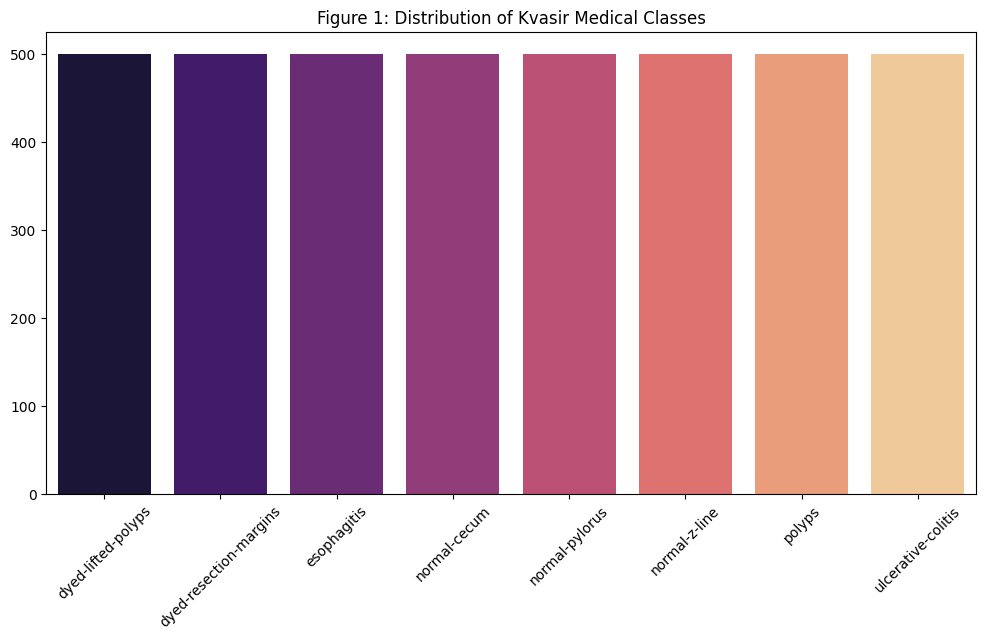

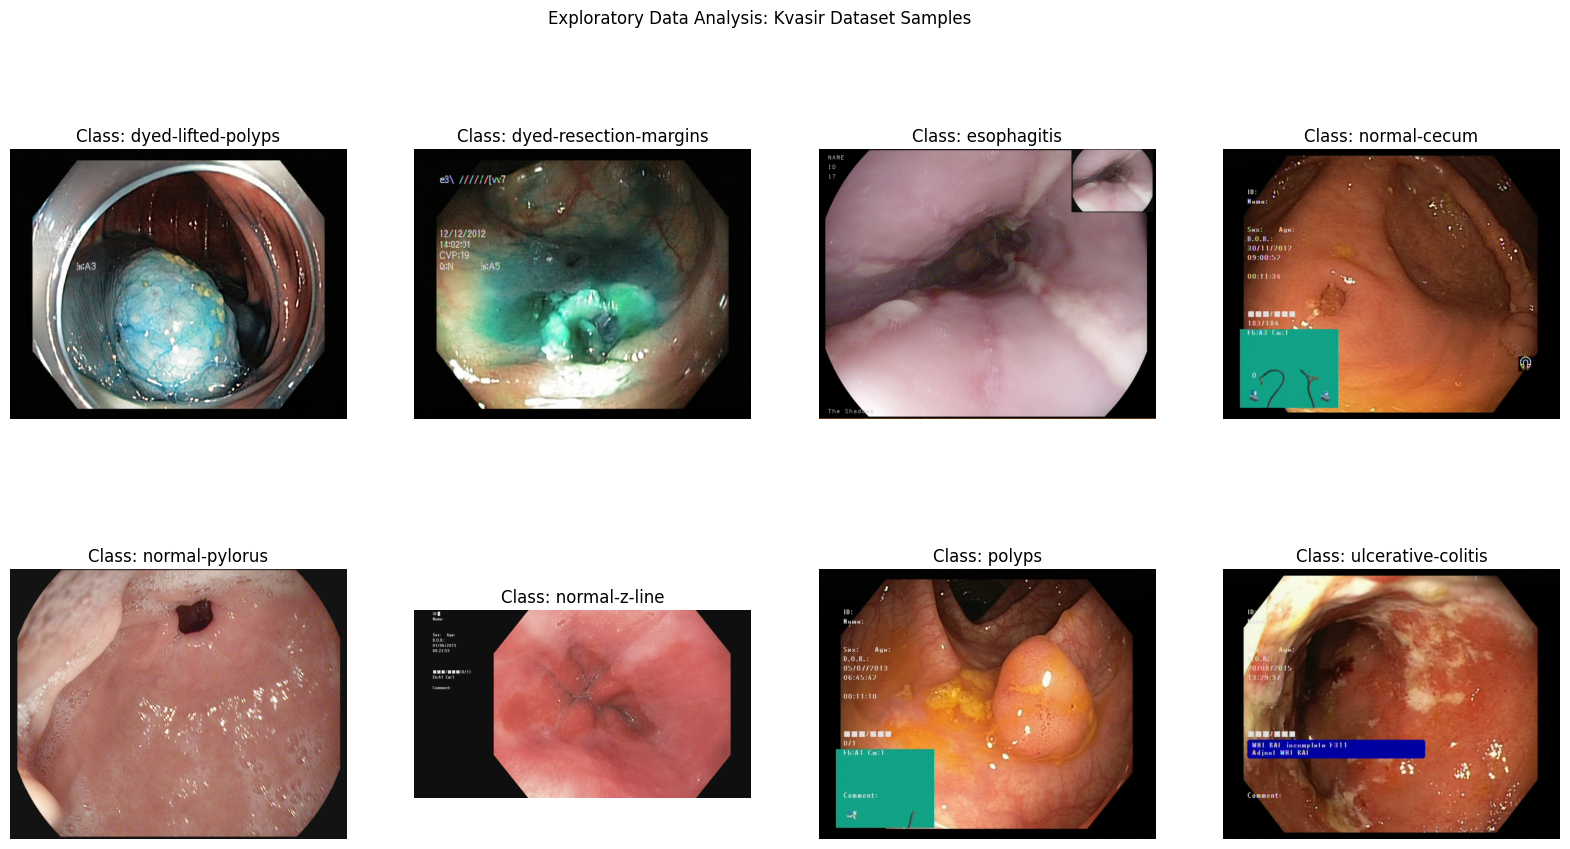

In [ ]:
# 2.1 Class Distribution (Requirement 1.d)
counts = {c: len(os.listdir(os.path.join(data_path, c))) for c in class_names}
plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), hue=list(counts.keys()), palette="magma", legend=False)
plt.xticks(rotation=45)
plt.title("Figure 1: Distribution of Kvasir Medical Classes")
plt.show()

# 2.2 Sample Visualization (Requirement 1.d)
plt.figure(figsize=(20, 10))
for i, label in enumerate(class_names):
    folder = os.path.join(data_path, label)
    img_list = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    img_path = os.path.join(folder, img_list[0])
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {label}")
    plt.axis("off")
plt.suptitle("Exploratory Data Analysis: Kvasir Dataset Samples")
plt.show()

3.0 Preprocessing & Augmentation

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255, 
    validation_split=0.3, 
    rotation_range=20,    
    horizontal_flip=True, 
    brightness_range=[0.8, 1.2]
)

print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    data_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True)

print("\nLoading Validation/Test Data:")
val_generator = train_datagen.flow_from_directory(
    data_path, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False)

print(f"\nClass Mappings: {train_generator.class_indices}")

Loading Training Data:
Found 2800 images belonging to 8 classes.

Loading Validation/Test Data:
Found 1200 images belonging to 8 classes.

Class Mappings: {'dyed-lifted-polyps': 0, 'dyed-resection-margins': 1, 'esophagitis': 2, 'normal-cecum': 3, 'normal-pylorus': 4, 'normal-z-line': 5, 'polyps': 6, 'ulcerative-colitis': 7}


4.0 Model Development & Evaluation

4.1 Custom CNN

In [ ]:
# Function for Custom CNN
def build_custom_cnn(num_classes):
    custom_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    
    # Dense Layer with L2 Regularization
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)), #
    layers.Dropout(0.5), 
    layers.Dense(len(class_names), activation='softmax')
    
    ])

    # Compile the model
    custom_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )
    return custom_model

# Define Custom CNN
custom_model = build_custom_cnn(len(class_names))

print("🔍 Reviewing Custom CNN Architecture...")
custom_model.summary()

🔍 Reviewing Custom CNN Architecture...


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     6,422,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,516,360 (24.86 MB)

 Trainable params: 6,516,360 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Setup Early Stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, 
    restore_best_weights=True 
)

print("🚀 Starting Training: Custom CNN...")
start = time.time()
history_custom = custom_model.fit(
    train_generator, 
    validation_data=val_generator, 
    epochs=20, 
    callbacks=[early_stop]
)
time_custom = time.time() - start

print(f"✅ Custom CNN Training Complete. Time: {time_custom:.2f}s")

🚀 Starting Training: Custom CNN...


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.2192 - loss: 2.1139 - val_accuracy: 0.4975 - val_loss: 1.7580
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.4009 - loss: 1.7123 - val_accuracy: 0.5883 - val_loss: 1.4153
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.4376 - loss: 1.4831 - val_accuracy: 0.5825 - val_loss: 1.2390
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - accuracy: 0.4677 - loss: 1.3787 - val_accuracy: 0.6133 - val_loss: 1.1141
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.4805 - loss: 1.2788 - val_accuracy: 0.6333 - val_loss: 1.0492
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.5111 - loss: 1.2372 - val_accuracy: 0.5900 - val_loss: 1.0087
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.5362 - loss: 1.1750 - val_accuracy: 0.6258 - val_loss: 0.9782
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.5564 - loss: 1.1546 - val_accuracy: 0.6050 - v

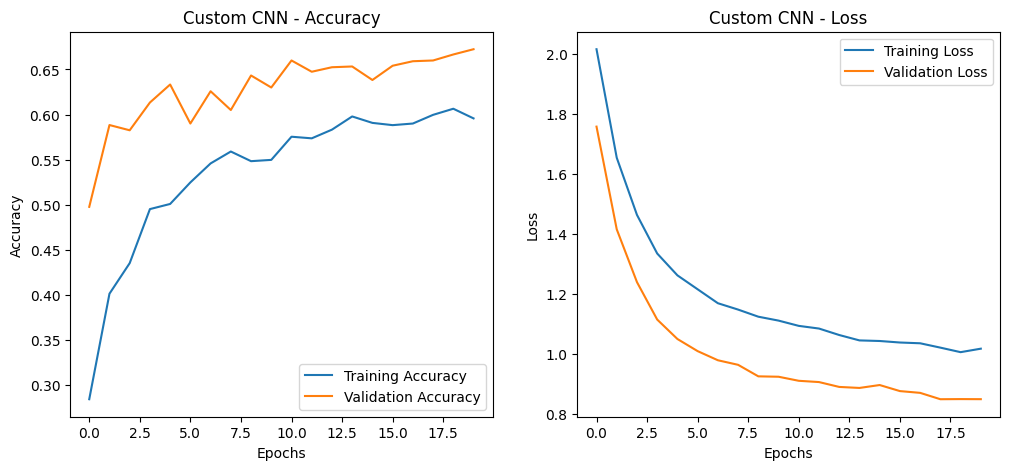

38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 483ms/step
--- Custom CNN Classification Report ---
                        precision    recall  f1-score   support

    dyed-lifted-polyps       0.54      0.26      0.35       150
dyed-resection-margins       0.53      0.79      0.63       150
           esophagitis       0.69      0.74      0.71       150
          normal-cecum       0.63      0.92      0.75       150
        normal-pylorus       0.85      0.85      0.85       150
         normal-z-line       0.66      0.65      0.66       150
                polyps       0.71      0.43      0.53       150
    ulcerative-colitis       0.76      0.69      0.72       150

              accuracy                           0.67      1200
             macro avg       0.67      0.67      0.65      1200
          weighted avg       0.67      0.67      0.65      1200



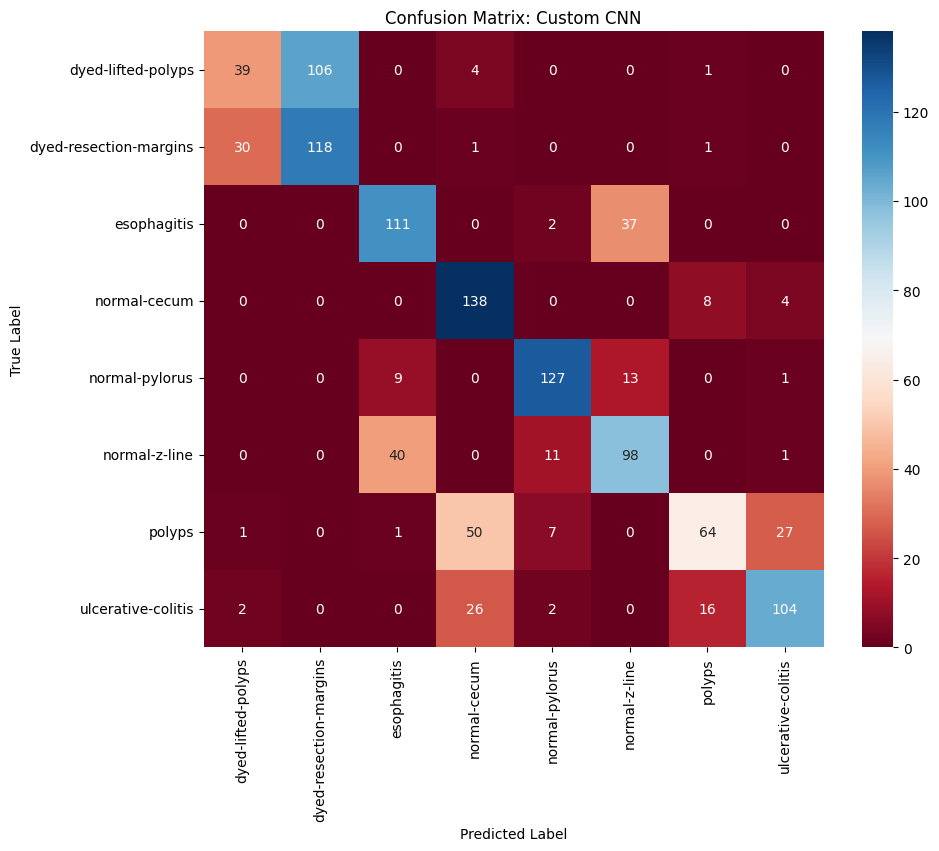

In [ ]:
# Accuracy and Loss Graphs
def plot_metrics(history, title):
    plt.figure(figsize=(12, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_metrics(history_custom, "Custom CNN")

# Confusion Matrix and Classification Report
Y_pred_custom = custom_model.predict(val_generator)
y_pred_custom = np.argmax(Y_pred_custom, axis=1)

print("--- Custom CNN Classification Report ---")
print(classification_report(val_generator.classes, y_pred_custom, target_names=class_names))

plt.figure(figsize=(10, 8))
cm_custom = confusion_matrix(val_generator.classes, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='RdBu', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Custom CNN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

4.2 MobileNetV2 (Pre-trained Model)

In [ ]:
# Function for MobileNetV2 (Transfer Learning)
def build_optimized_mobilenet(num_classes):
    base_mobile = tf.keras.applications.MobileNetV2(
        weights='imagenet', 
        include_top=False, 
        input_shape=(224, 224, 3)
        )
    # Unfreeze the base model for fine-tuning
    base_mobile.trainable = True
    for layer in base_mobile.layers[:-30]: 
        layer.trainable = False

    # Rebuild the Classifier Head
    mobile_model = models.Sequential([
        base_mobile,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Compile the model
    mobile_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
        loss='categorical_crossentropy', 
        metrics=['accuracy']
    )
    return mobile_model

# Define MobileNetV2
mobile_model = build_optimized_mobilenet(len(class_names))

print("\n🔍 Reviewing MobileNetV2 Architecture...")
mobile_model.summary()


🔍 Reviewing MobileNetV2 Architecture...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,976 (9.87 MB)

 Trainable params: 1,856,392 (7.08 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [ ]:
# Define Callbacks
lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)

# 5. TRAIN the model (Single call with timing)
print("🚀 Starting Training: MobileNetV2...")
start_mobile = time.time() # Start timer specifically for MobileNet

history_mobile = mobile_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[lr_scheduler] # Keep your scheduler active
)

time_mobile = time.time() - start_mobile # Calculate duration
print(f"✅ MobileNetV2 Training Complete. Time: {time_mobile:.2f}s")

🚀 Starting Training: MobileNetV2...
Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 87s 906ms/step - accuracy: 0.1721 - loss: 2.2578 - val_accuracy: 0.2558 - val_loss: 2.0252 - learning_rate: 1.0000e-05
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 77s 874ms/step - accuracy: 0.3634 - loss: 1.6944 - val_accuracy: 0.3300 - val_loss: 1.7385 - learning_rate: 1.0000e-05
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 78s 886ms/step - accuracy: 0.5435 - loss: 1.2945 - val_accuracy: 0.4117 - val_loss: 1.5424 - learning_rate: 1.0000e-05
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 84s 950ms/step - accuracy: 0.6467 - loss: 1.0391 - val_accuracy: 0.4792 - val_loss: 1.3717 - learning_rate: 1.0000e-05
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 82s 928ms/step - accuracy: 0.6795 - loss: 0.9065 - val_accuracy: 0.5367 - val_loss: 1.2656 - learning_rate: 1.0000e-05
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.7260 - loss: 0.7825 - val_accuracy: 0.6100 - val_loss: 1.0702 - learning_rate: 1.0000e-05
Epoch 7/20
88/88 ━━━━━━━━

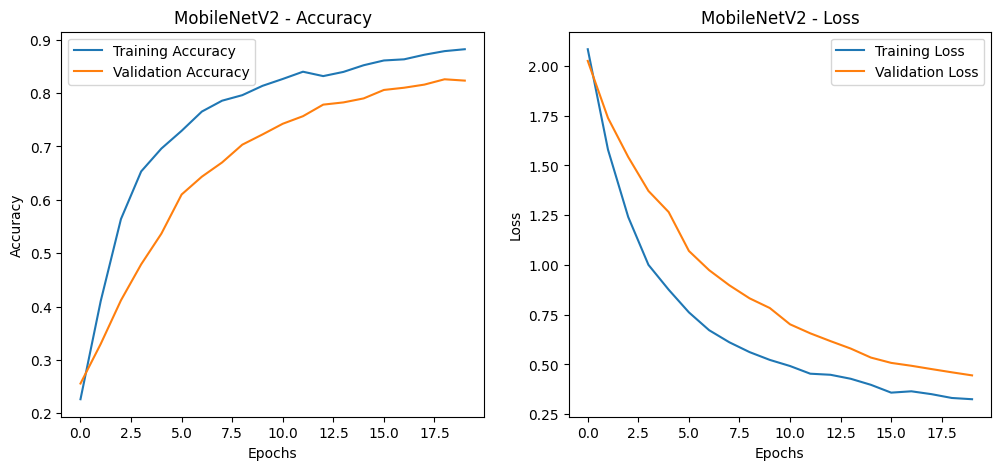

38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 709ms/step
--- MobileNetV2 Classification Report ---
                        precision    recall  f1-score   support

    dyed-lifted-polyps       0.76      0.83      0.79       150
dyed-resection-margins       0.89      0.66      0.76       150
           esophagitis       0.94      0.65      0.77       150
          normal-cecum       0.86      0.98      0.92       150
        normal-pylorus       0.94      0.99      0.96       150
         normal-z-line       0.72      0.94      0.81       150
                polyps       0.84      0.81      0.82       150
    ulcerative-colitis       0.90      0.89      0.90       150

              accuracy                           0.84      1200
             macro avg       0.86      0.84      0.84      1200
          weighted avg       0.86      0.84      0.84      1200



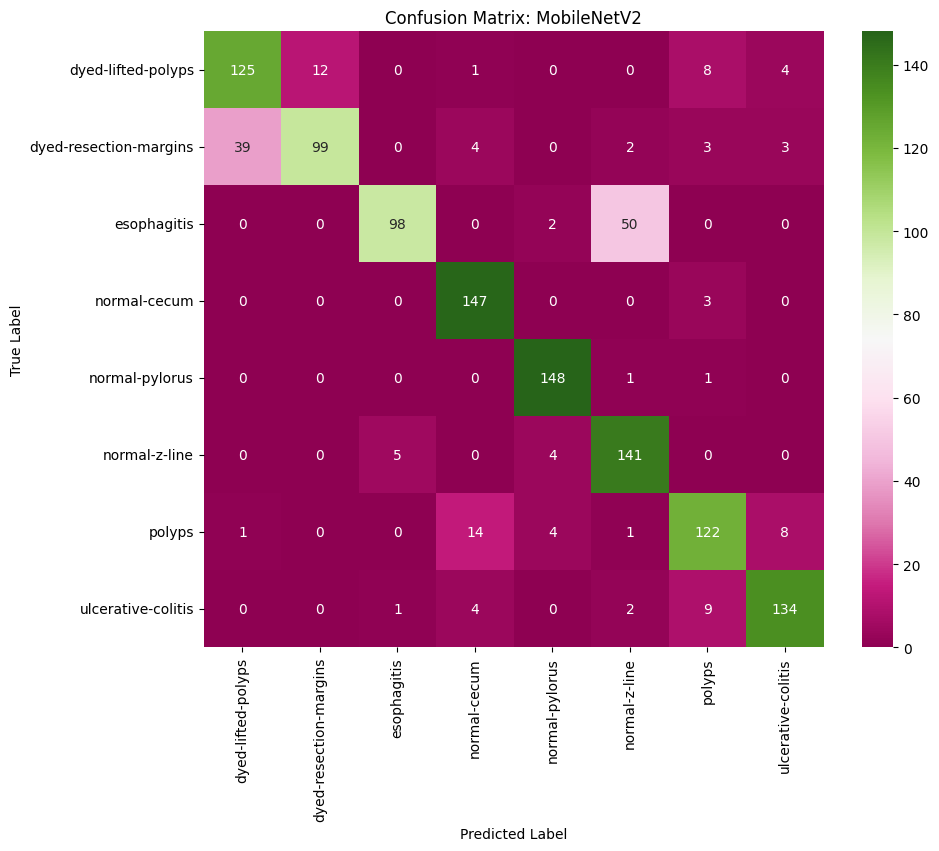

In [ ]:
# Accuracy and Loss Graphs
plot_metrics(history_mobile, "MobileNetV2")

# Confusion Matrix and Classification Report
Y_pred_mobile = mobile_model.predict(val_generator)
y_pred_mobile = np.argmax(Y_pred_mobile, axis=1)

print("--- MobileNetV2 Classification Report ---")
print(classification_report(val_generator.classes, y_pred_mobile, target_names=class_names))

plt.figure(figsize=(10, 8))
cm_mobile = confusion_matrix(val_generator.classes, y_pred_mobile)
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='PiYG', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: MobileNetV2')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

5.0 Final Comparison Table

--- FINAL PROJECT PERFORMANCE COMPARISON ---
--------------------------------------------------
Model Name:        Custom CNN
Training Time:     3021.68 seconds
Best Val Accuracy:  0.6725
Final Training Loss: 1.0169
Complexity:        Low (Lightweight)
--------------------------------------------------
Model Name:        MobileNetV2 (Transfer Learning)
Training Time:     2043.41 seconds
Best Val Accuracy:  0.8258
Final Training Loss: 0.3250
Complexity:        High (Pre-trained)
--------------------------------------------------


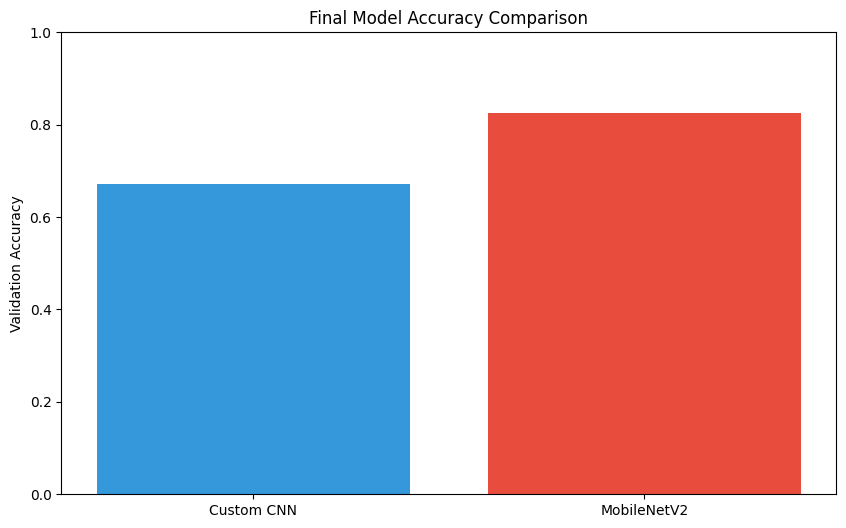

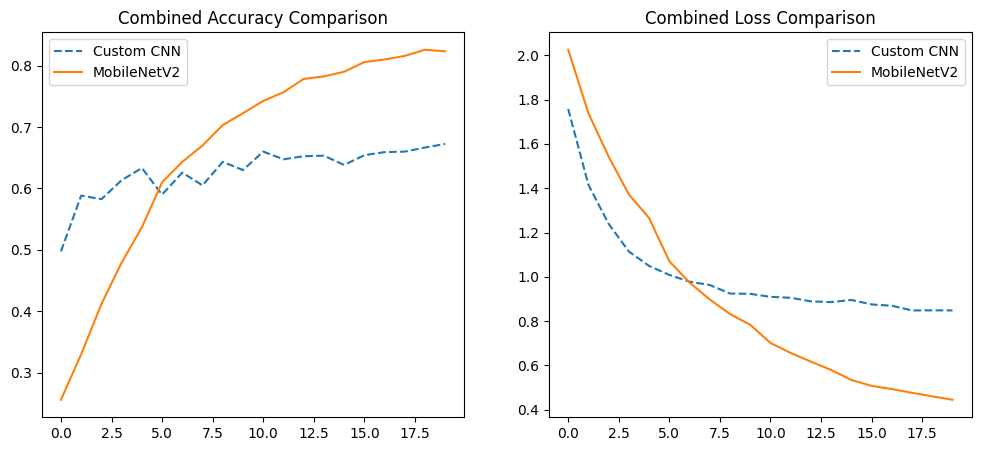

In [ ]:
# 5.1 Final Comparison Results Summary [CLO3]
print("--- FINAL PROJECT PERFORMANCE COMPARISON ---")
print("-" * 50)

# Collecting data from variables defined in previous cells
models_to_compare = [
    ("Custom CNN", history_custom, time_custom),
    ("MobileNetV2 (Transfer Learning)", history_mobile, time_mobile)
]

for name, history, duration in models_to_compare:
    # Get the best validation accuracy achieved during training 
    best_val_acc = max(history.history['val_accuracy'])
    # Get the final training loss 
    final_loss = history.history['loss'][-1]
    
    print(f"Model Name:        {name}")
    print(f"Training Time:     {duration:.2f} seconds") 
    print(f"Best Val Accuracy:  {best_val_acc:.4f}")      
    print(f"Final Training Loss: {final_loss:.4f}")
    
    # Logic to describe complexity
    complexity_str = 'Low (Lightweight)' if 'Custom' in name else 'High (Pre-trained)'
    print(f"Complexity:        {complexity_str}")
    print("-" * 50)

# Visual comparison of Accuracy
plt.figure(figsize=(10, 6))
plt.bar(['Custom CNN', 'MobileNetV2'], 
        [max(history_custom.history['val_accuracy']), max(history_mobile.history['val_accuracy'])],
        color=['#3498db', '#e74c3c'])
plt.ylabel('Validation Accuracy')
plt.title('Final Model Accuracy Comparison')
plt.ylim(0, 1.0)
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_custom.history['val_accuracy'], label='Custom CNN', linestyle='--')
plt.plot(history_mobile.history['val_accuracy'], label='MobileNetV2')
plt.title("Combined Accuracy Comparison"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_custom.history['val_loss'], label='Custom CNN', linestyle='--')
plt.plot(history_mobile.history['val_loss'], label='MobileNetV2')
plt.title("Combined Loss Comparison"); plt.legend()
plt.show()

6.0 Demonstration

In [ ]:
# Save the trained models to your local folder
custom_model.save('custom_medical_model.h5')
mobile_model.save('mobile_medical_model.h5')

print("✅ Models saved successfully as .h5 files!")

✅ Models saved successfully as .h5 files!


--- 🚀 Medical Image Classification Demo ---
📦 Loading saved models from disk...


Opening file selector... Please select a medical image.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step


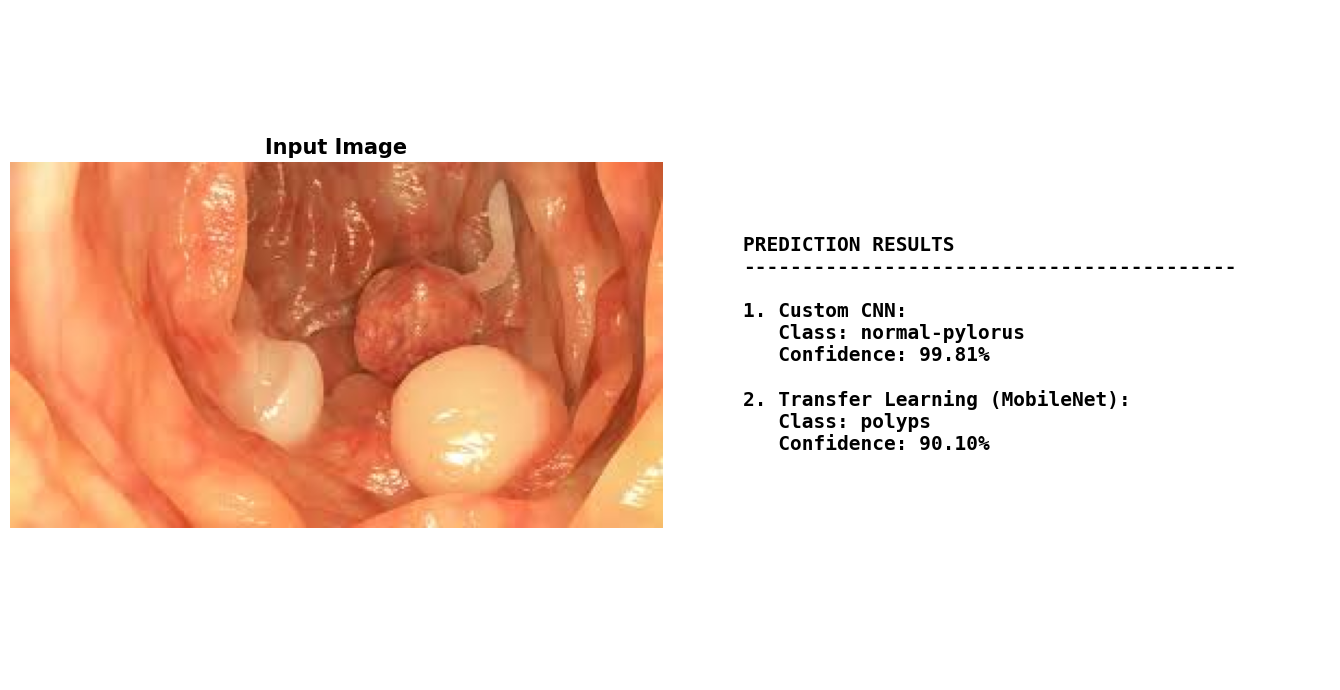

In [ ]:
def run_prediction_demo():
    print("--- 🚀 Medical Image Classification Demo ---")
    
    # --- 1. Load models from saved files ---
    # This part checks if you have already saved your models
    custom_path = 'custom_medical_model.h5'
    mobile_path = 'mobile_medical_model.h5'
    
    if os.path.exists(custom_path) and os.path.exists(mobile_path):
        print("📦 Loading saved models from disk...")
        c_model = load_model(custom_path)
        m_model = load_model(mobile_path)
    else:
        print("⚠️ Saved model files not found. Using models from current session memory...")
        # Fallback to the variables in memory if files aren't found
        c_model = custom_model 
        m_model = mobile_model

    # --- 2. File Picker ---
    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    
    print("Opening file selector... Please select a medical image.")
    file_path = filedialog.askopenfilename(
        title="Select Medical Image",
        filetypes=[("Image files", "*.jpg *.jpeg *.png")]
    )
    
    if not file_path:
        print("❌ No file selected. Exiting demo.")
        root.destroy()
        return

    # --- 3. Preprocess the Image ---
    img = cv2.imread(file_path)
    if img is None:
        print("❌ Error: Could not read the image.")
        root.destroy()
        return
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_normalized = img_resized / 255.0
    img_final = np.expand_dims(img_normalized, axis=0)

    # --- 4. Get Predictions ---
    pred_c = c_model.predict(img_final)
    idx_c = np.argmax(pred_c)
    conf_c = np.max(pred_c) * 100

    pred_m = m_model.predict(img_final)
    idx_m = np.argmax(pred_m)
    conf_m = np.max(pred_m) * 100

    # --- 5. Create the Visual Output ---
    plt.figure(figsize=(14, 7))

    # Left Side: Image
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title("Input Image", fontsize=15, fontweight='bold')
    plt.axis('off')

    # Right Side: Prediction Text
    plt.subplot(1, 2, 2)
    plt.axis('off')
    
    result_text = (
        f"PREDICTION RESULTS\n"
        f"------------------------------------------\n\n"
        f"1. Custom CNN:\n"
        f"   Class: {class_names[idx_c]}\n"
        f"   Confidence: {conf_c:.2f}%\n\n"
        f"2. Transfer Learning (MobileNet):\n"
        f"   Class: {class_names[idx_m]}\n"
        f"   Confidence: {conf_m:.2f}%"
    )
    
    plt.text(0.1, 0.5, result_text, fontsize=14, family='monospace', 
             verticalalignment='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
    root.destroy()

# Run the function
run_prediction_demo()